# ПРОГНОЗИРОВАНИЕ КОНЕЧНЫХ СВОЙСТВ КОМПОЗИТНЫХ МАТЕРИАЛОВ. ЧАСТЬ1
# 1. ПОДГОТОВКА ТАБЛИЧНЫХ ДАННЫХ ДЛЯ АНАЛИЗА

In [69]:
# Загружаем основные библиотеки для работы с данными
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
matplotlib.style.use('default')

In [2]:
# Загружаем архивные файлы характеристик композитов (датасеты) с URL с помощью инструмента загрузки больших файлов
!pip install gdown
import gdown
url = 'https://drive.google.com/uc?id=1B1s5gBlvgU81H9GGolLQVw_SOi-vyNf2'
output = 'hw_data_composite.zip'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1B1s5gBlvgU81H9GGolLQVw_SOi-vyNf2
To: C:\Users\User\Desktop\Data Science\Проект прогноз\hw_data_composite.zip
100%|████████████████████████████████████████████████████████████████████████████████| 178k/178k [00:00<00:00, 978kB/s]


'hw_data_composite.zip'

In [3]:
# Извлекаем 2 excel-файла данных из архива Zip и выводим таблицы с показателями на экран
import pandas as pd
from zipfile import ZipFile
with ZipFile("hw_data_composite.zip", "r") as myzip:
    myzip.extractall()
df1 = pd.read_excel('X_bp.xlsx') 
df2 = pd.read_excel('X_nup.xlsx')

In [7]:
df1

,Unnamed: 0,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2"
0,0,1.857143,2030.000000,738.736842,30.000000,22.267857,100.000000,210.000000,70.000000,3000.000000,220.000000
1,1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000
2,2,1.857143,2030.000000,738.736842,49.900000,33.000000,284.615385,210.000000,70.000000,3000.000000,220.000000
3,3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000
4,4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000
...,...,...,...,...,...,...,...,...,...,...,...
1018,1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669
1019,1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099
1020,1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764
1021,1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067


In [8]:
df2

,Unnamed: 0,"Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,0,0,4.000000,57.000000
1,1,0,4.000000,60.000000
2,2,0,4.000000,70.000000
3,3,0,5.000000,47.000000
4,4,0,5.000000,57.000000
...,...,...,...,...
1035,1035,90,8.088111,47.759177
1036,1036,90,7.619138,66.931932
1037,1037,90,9.800926,72.858286
1038,1038,90,10.079859,65.519479


In [5]:
# В соответствии с заданием объединяем таблицы по индексу, используя метод INNER.
df = df1.merge(df2, how='inner', on='Unnamed: 0')

# Столбец "Unnamed:0", не содержащий значимой информации, целесообразно удалить.
df = df.drop('Unnamed: 0', axis=1)
df

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.000000,738.736842,30.000000,22.267857,100.000000,210.000000,70.000000,3000.000000,220.000000,0,4.000000,57.000000
1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,60.000000
2,1.857143,2030.000000,738.736842,49.900000,33.000000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,70.000000
3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000,0,5.000000,47.000000
4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,57.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669,90,9.076380,47.019770
1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099,90,10.565614,53.750790
1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764,90,4.161154,67.629684
1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067,90,6.313201,58.261074


# 2. РАЗВЕДОЧНЫЙ АНАЛИЗ ДАННЫХ

In [6]:
# В наборе данных 13 столбцов и 1023 строки. 
# Получим по ним общую информацию: 12 столбцов с дробными значениями данных и 1 столбец - с целочисленными значениями. Пропусков значений нет. 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       1023 non-null   float64
 1   Плотность, кг/м3                      1023 non-null   float64
 2   модуль упругости, ГПа                 1023 non-null   float64
 3   Количество отвердителя, м.%           1023 non-null   float64
 4   Содержание эпоксидных групп,%_2       1023 non-null   float64
 5   Температура вспышки, С_2              1023 non-null   float64
 6   Поверхностная плотность, г/м2         1023 non-null   float64
 7   Модуль упругости при растяжении, ГПа  1023 non-null   float64
 8   Прочность при растяжении, МПа         1023 non-null   float64
 9   Потребление смолы, г/м2               1023 non-null   float64
 10  Угол нашивки, град                    1023 non-null   int64  
 11  Шаг нашивки      

In [11]:
# Проверим наличие дубликатов 
duplicates = df.duplicated()
num_duplicates = duplicates.sum()

In [10]:
# Проверим наличие пропущенных значений
df.isnull().sum()

Соотношение матрица-наполнитель         0
Плотность, кг/м3                        0
модуль упругости, ГПа                   0
Количество отвердителя, м.%             0
Содержание эпоксидных групп,%_2         0
Температура вспышки, С_2                0
Поверхностная плотность, г/м2           0
Модуль упругости при растяжении, ГПа    0
Прочность при растяжении, МПа           0
Потребление смолы, г/м2                 0
Угол нашивки, град                      0
Шаг нашивки                             0
Плотность нашивки                       0
dtype: int64

In [7]:
# Описательная статистика данных, представленных в полученной таблице-датасете
df.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000,1023.000000
mean,2.930366,1975.734888,739.923233,110.570769,22.244390,285.882151,482.731833,73.328571,2466.922843,218.423144,44.252199,6.899222,57.153929
std,0.913222,73.729231,330.231581,28.295911,2.406301,40.943260,281.314690,3.118983,485.628006,59.735931,45.015793,2.563467,12.350969
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.000000,0.000000
25%,2.317887,1924.155467,500.047452,92.443497,20.608034,259.066528,266.816645,71.245018,2135.850448,179.627520,0.000000,5.080033,49.799212
50%,2.906878,1977.621657,739.664328,110.564840,22.230744,285.896812,451.864365,73.268805,2459.524526,219.198882,0.000000,6.916144,57.341920
75%,3.552660,2021.374375,961.812526,129.730366,23.961934,313.002106,693.225017,75.356612,2767.193119,257.481724,90.000000,8.586293,64.944961
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


In [13]:
# По результатам описательной статистики можно сделать ряд наблюдений:
# - переменная "угол нашивки" принимает в данной выборке только два варианта значений (0 или 90); 
# - в переменных "шаг нашивки" и "плотность нашивки" есть строки с нулевыми значениями;
# - ряд переменных имеют существенный размах значений и стандартное отклонение.

In [8]:
# Посмотрим на размах значений изучаемых переменных показателей-физико-механических характеристик композитов
df.apply(lambda x: x.max() - x.min()) 

Соотношение матрица-наполнитель            5.202339
Плотность, кг/м3                         476.008846
модуль упругости, ГПа                   1909.099568
Количество отвердителя, м.%              181.212933
Содержание эпоксидных групп,%_2           18.745015
Температура вспышки, С_2                 313.273418
Поверхностная плотность, г/м2           1398.938622
Модуль упругости при растяжении, ГПа      18.627990
Прочность при растяжении, МПа           2811.580127
Потребление смолы, г/м2                  380.787603
Угол нашивки, град                        90.000000
Шаг нашивки                               14.440522
Плотность нашивки                        103.988901
dtype: float64

In [9]:
# Рассчитаем коэффициенты вариации, как относительную меру изменчивости изучаемого признака
df.apply(lambda x: x.std() / x.mean())
# Значения коэффициентов вариации больше 33% (0,33) свидетельствуют о высокой неоднородности информации
# и необходимости исключения возможных аномалий (выбросов) или принадлежности части данных к другой группе объектов.

Соотношение матрица-наполнитель         0.311641
Плотность, кг/м3                        0.037317
модуль упругости, ГПа                   0.446305
Количество отвердителя, м.%             0.255908
Содержание эпоксидных групп,%_2         0.108176
Температура вспышки, С_2                0.143217
Поверхностная плотность, г/м2           0.582756
Модуль упругости при растяжении, ГПа    0.042534
Прочность при растяжении, МПа           0.196856
Потребление смолы, г/м2                 0.273487
Угол нашивки, град                      1.017256
Шаг нашивки                             0.371559
Плотность нашивки                       0.216100
dtype: float64

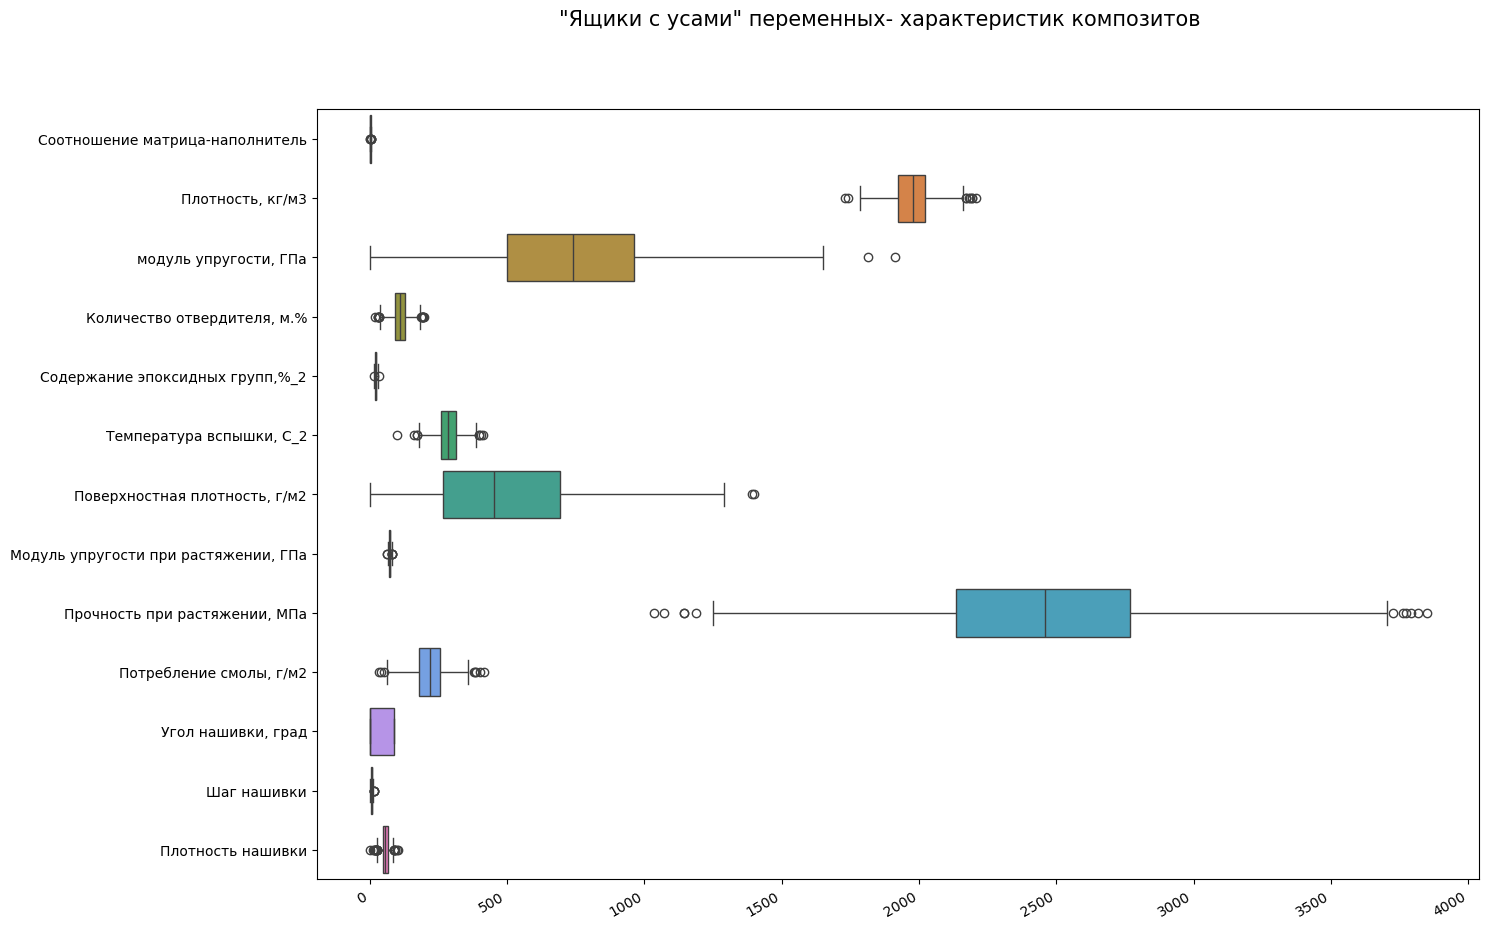

In [10]:
# Наличие выбросов наглядно продемонстрируем с помощью нескольких вариантов графиков:
# -"ящиков с усами" для каждой переменной
plt.figure(figsize=(15,10))
plt.suptitle('"Ящики с усами" переменных- характеристик композитов', fontsize = 15)
sns.boxplot(data=df, orient="h")
plt.xticks(rotation=30, ha='right')
plt.show()

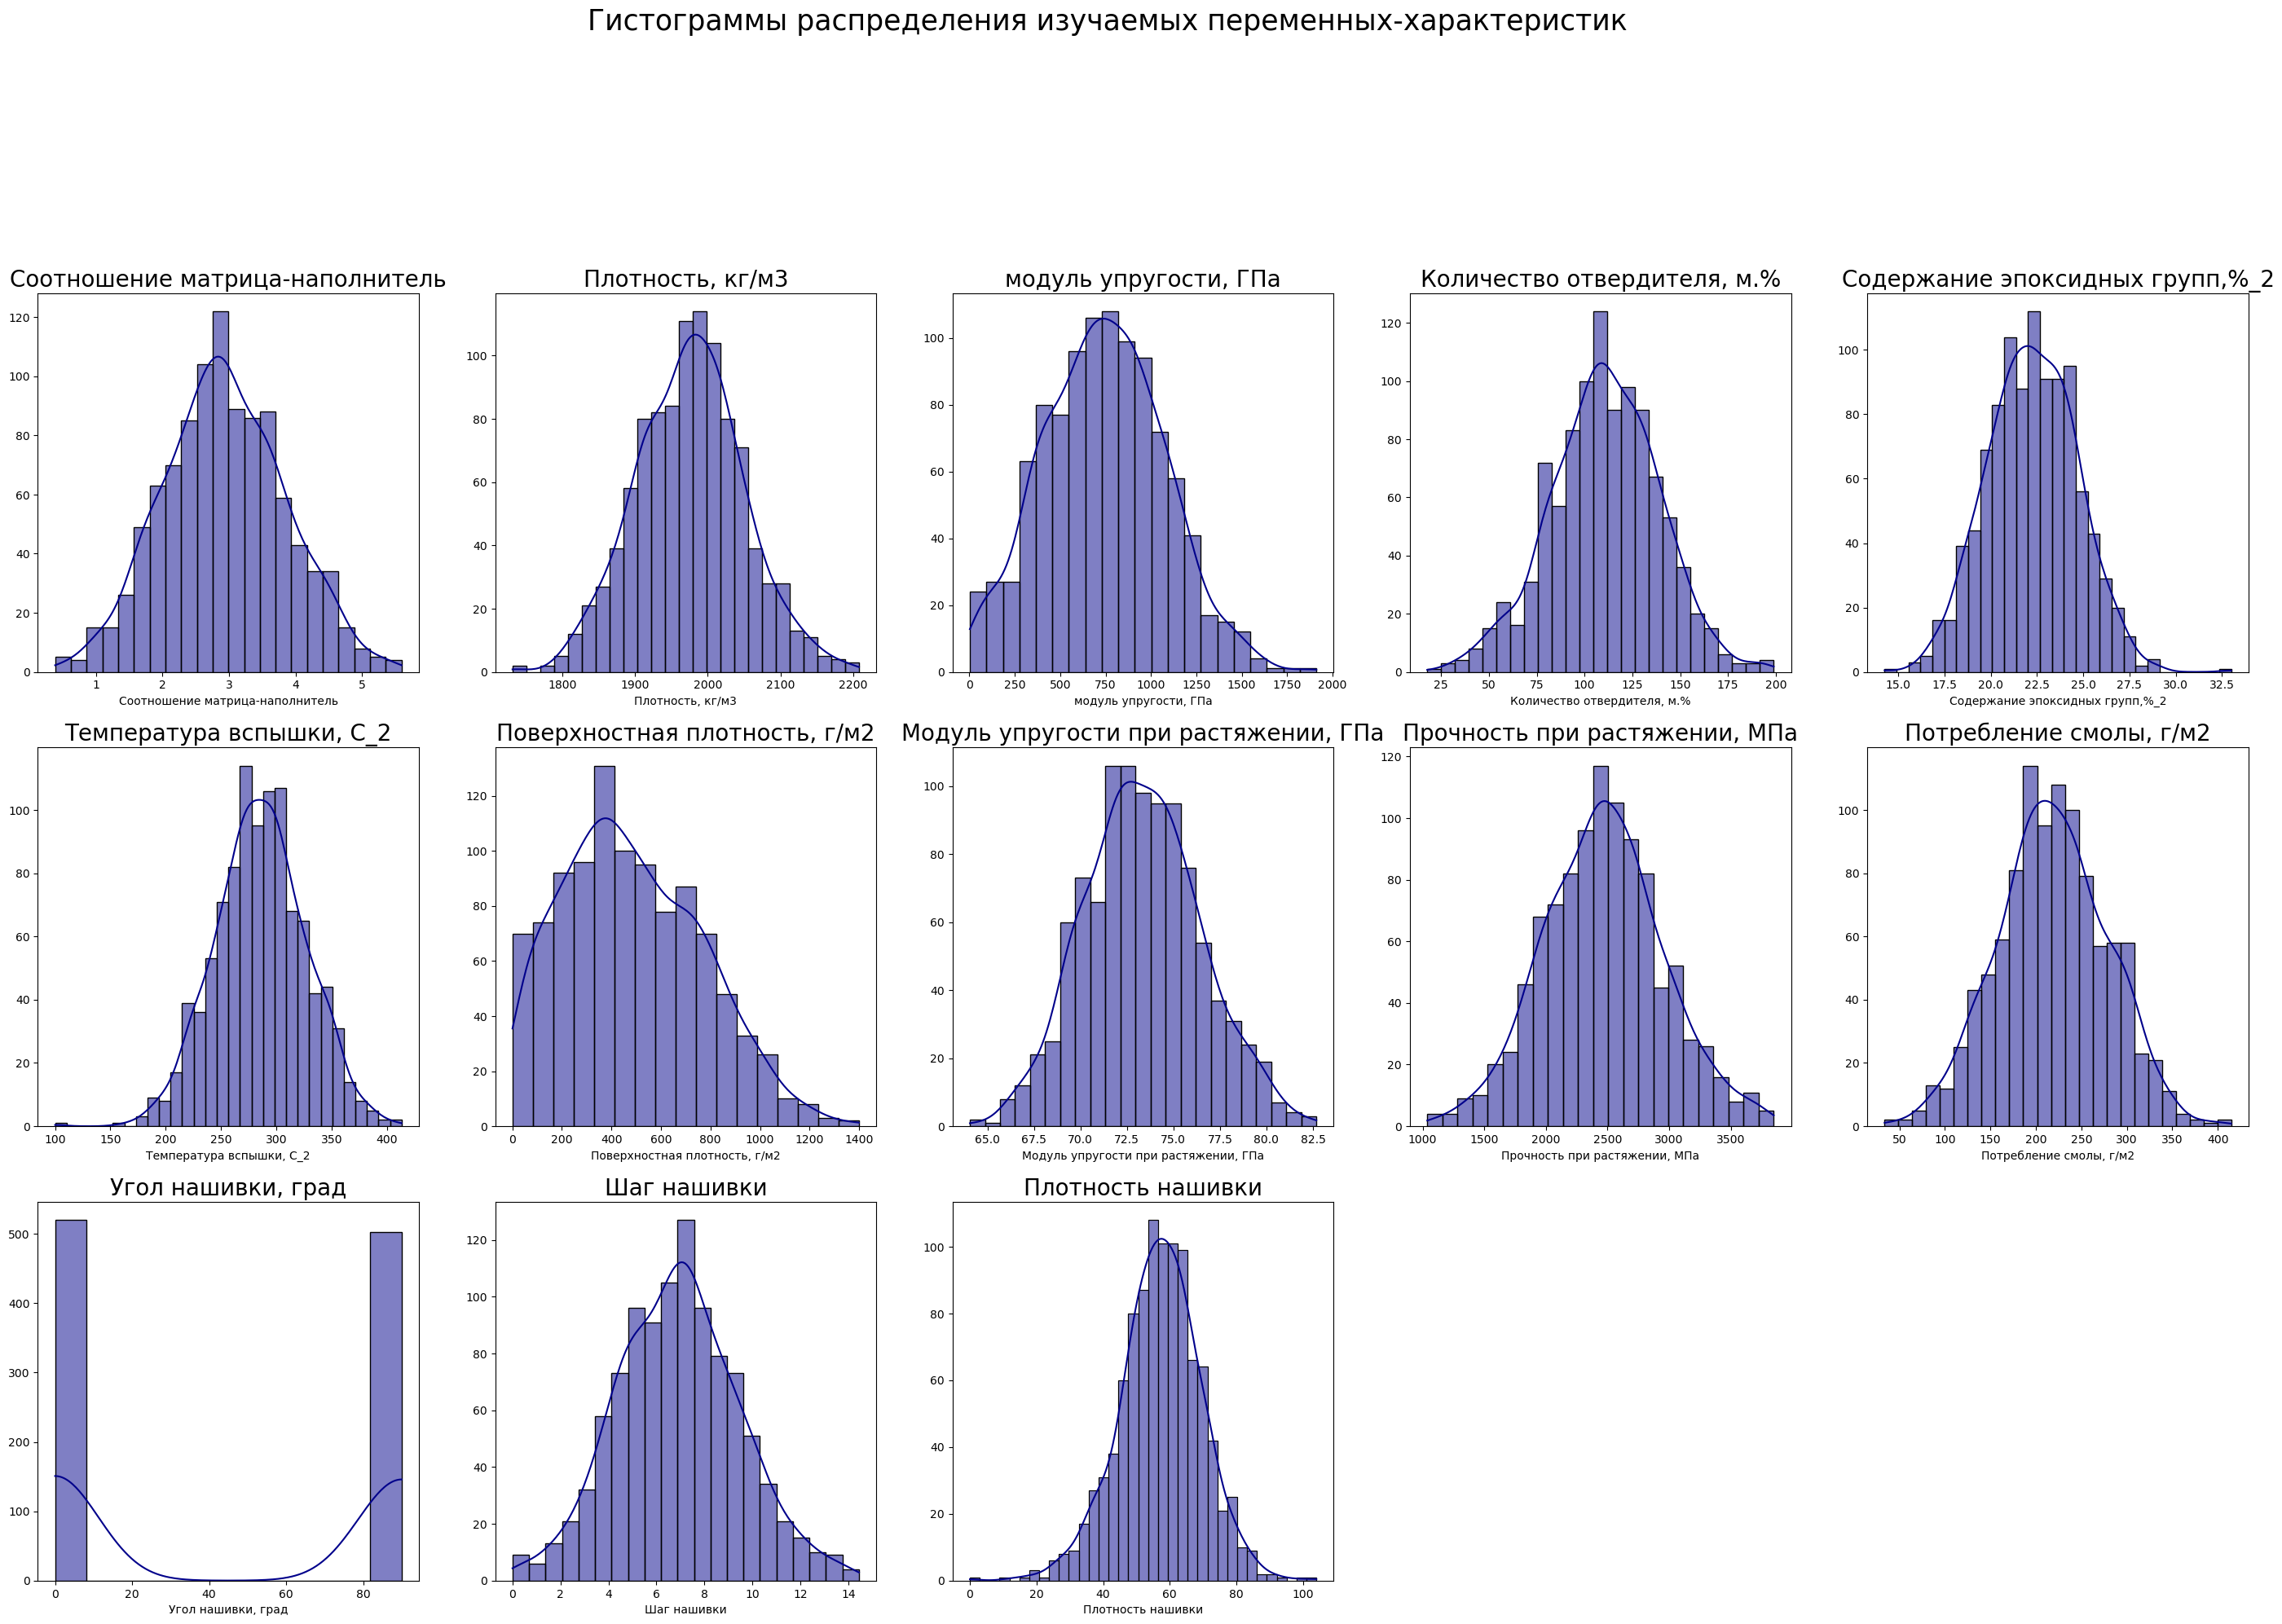

In [23]:
#- гистограмм распределения для каждой переменной, которые наглядно позволяют оценить близость распределения к нормальному и асимметрию
df.columns
column_names = df.columns
a = 5 # количество строк
b = 5 # количество столцбцов
c = 1 # запуск plot counter
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (35,35))
plt.suptitle('Гистограммы распределения изучаемых переменных-характеристик', fontsize = 25)
for col in df.columns:
    plt.subplot(a, b, c)
    sns.histplot(data = df[col], kde=True, color = "darkblue")
    plt.ylabel(None)
    plt.title(col, size = 20)
    c += 1

In [11]:
# Найдем и удалим строку с нулевым значением показателей "шаг нашивки" и "плотность нашивки"
df.loc[df['Плотность нашивки'] == 0]
df_new = df[df['Плотность нашивки'] != 0]
df_new.shape

(1022, 13)

In [162]:
# Описательная статистика полученного датасета
df_new.describe()
# Учитывая физико-механические свойства композитных материалов и используемых в них армирующих волокон, имеют место выбросы,
# прежде всего,в значениях переменных "модуль упругости" и "поверхностная плотность", которые также демонстрируют асимметрию 
# со смещением влево. Большая часть переменных по значениям близка к нормальному распределению.

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000,1022.000000
mean,2.929777,1975.730715,739.489694,110.569507,22.244367,285.883391,482.215915,73.324000,2467.379714,218.343323,44.295499,6.905973,57.209853
std,0.913475,73.765207,330.101862,28.309736,2.407479,40.963286,280.967801,3.117080,485.645758,59.710570,45.016514,2.555608,12.226746
min,0.389403,1731.764635,2.436909,17.740275,14.254985,100.000000,0.603740,64.054061,1036.856605,33.803026,0.000000,0.037639,11.740126
25%,2.317247,1924.134147,499.321940,92.431413,20.607747,259.029216,266.654559,71.241213,2136.259145,179.604490,0.000000,5.081732,49.852483
50%,2.906630,1977.603973,739.310747,110.549159,22.230545,285.922290,451.588705,73.266770,2460.260972,219.189018,0.000000,6.922196,57.362576
75%,3.552781,2021.384103,960.465724,129.732521,23.962050,313.012786,692.342336,75.338920,2768.016102,257.399329,90.000000,8.586378,64.959026
max,5.591742,2207.773481,1911.536477,198.953207,33.000000,413.273418,1399.542362,82.682051,3848.436732,414.590628,90.000000,14.440522,103.988901


In [12]:
# Обратимся к корреляционной матрице для анализа типа и тесноты связи между переменными
df_new.corr()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
Соотношение матрица-наполнитель,1.000000,0.003805,0.030867,-0.006476,0.019764,-0.004757,-0.007496,-0.009390,0.024785,0.071730,-0.030459,0.038319,-0.001682
"Плотность, кг/м3",0.003805,1.000000,-0.009732,-0.035914,-0.008279,-0.020693,0.044901,-0.017706,-0.069958,-0.016029,-0.068451,-0.061080,0.081425
"модуль упругости, ГПа",0.030867,-0.009732,1.000000,0.024011,-0.006823,0.031243,-0.007789,0.021341,0.043189,0.000045,-0.024158,-0.006366,0.063148
"Количество отвердителя, м.%",-0.006476,-0.035914,0.024011,1.000000,-0.000684,0.095194,0.055209,-0.066068,-0.075366,0.007392,0.038633,0.015061,0.017640
"Содержание эпоксидных групп,%_2",0.019764,-0.008279,-0.006823,-0.000684,1.000000,-0.009769,-0.012980,0.056877,-0.023900,0.015165,0.008065,0.003059,-0.039445
"Температура вспышки, С_2",-0.004757,-0.020693,0.031243,0.095194,-0.009769,1.000000,0.020212,0.028491,-0.031807,0.060050,0.020675,0.025805,0.011371
"Поверхностная плотность, г/м2",-0.007496,0.044901,-0.007789,0.055209,-0.012980,0.020212,1.000000,0.034048,-0.001448,0.013220,0.054222,0.043502,-0.041942
"Модуль упругости при растяжении, ГПа",-0.009390,-0.017706,0.021341,-0.066068,0.056877,0.028491,0.034048,1.000000,-0.007610,0.049033,0.024484,-0.025639,0.013420
"Прочность при растяжении, МПа",0.024785,-0.069958,0.043189,-0.075366,-0.023900,-0.031807,-0.001448,-0.007610,1.000000,0.029929,0.022493,-0.062331,0.015416
"Потребление смолы, г/м2",0.071730,-0.016029,0.000045,0.007392,0.015165,0.060050,0.013220,0.049033,0.029929,1.000000,-0.014039,0.017070,0.018642


In [15]:
df_new.corr().min()


Соотношение матрица-наполнитель        -0.030459
Плотность, кг/м3                       -0.069958
модуль упругости, ГПа                  -0.024158
Количество отвердителя, м.%            -0.075366
Содержание эпоксидных групп,%_2        -0.039445
Температура вспышки, С_2               -0.031807
Поверхностная плотность, г/м2          -0.041942
Модуль упругости при растяжении, ГПа   -0.066068
Прочность при растяжении, МПа          -0.075366
Потребление смолы, г/м2                -0.016029
Угол нашивки, град                     -0.068451
Шаг нашивки                            -0.062331
Плотность нашивки                      -0.041942
dtype: float64

<Figure size 1600x800 with 0 Axes>

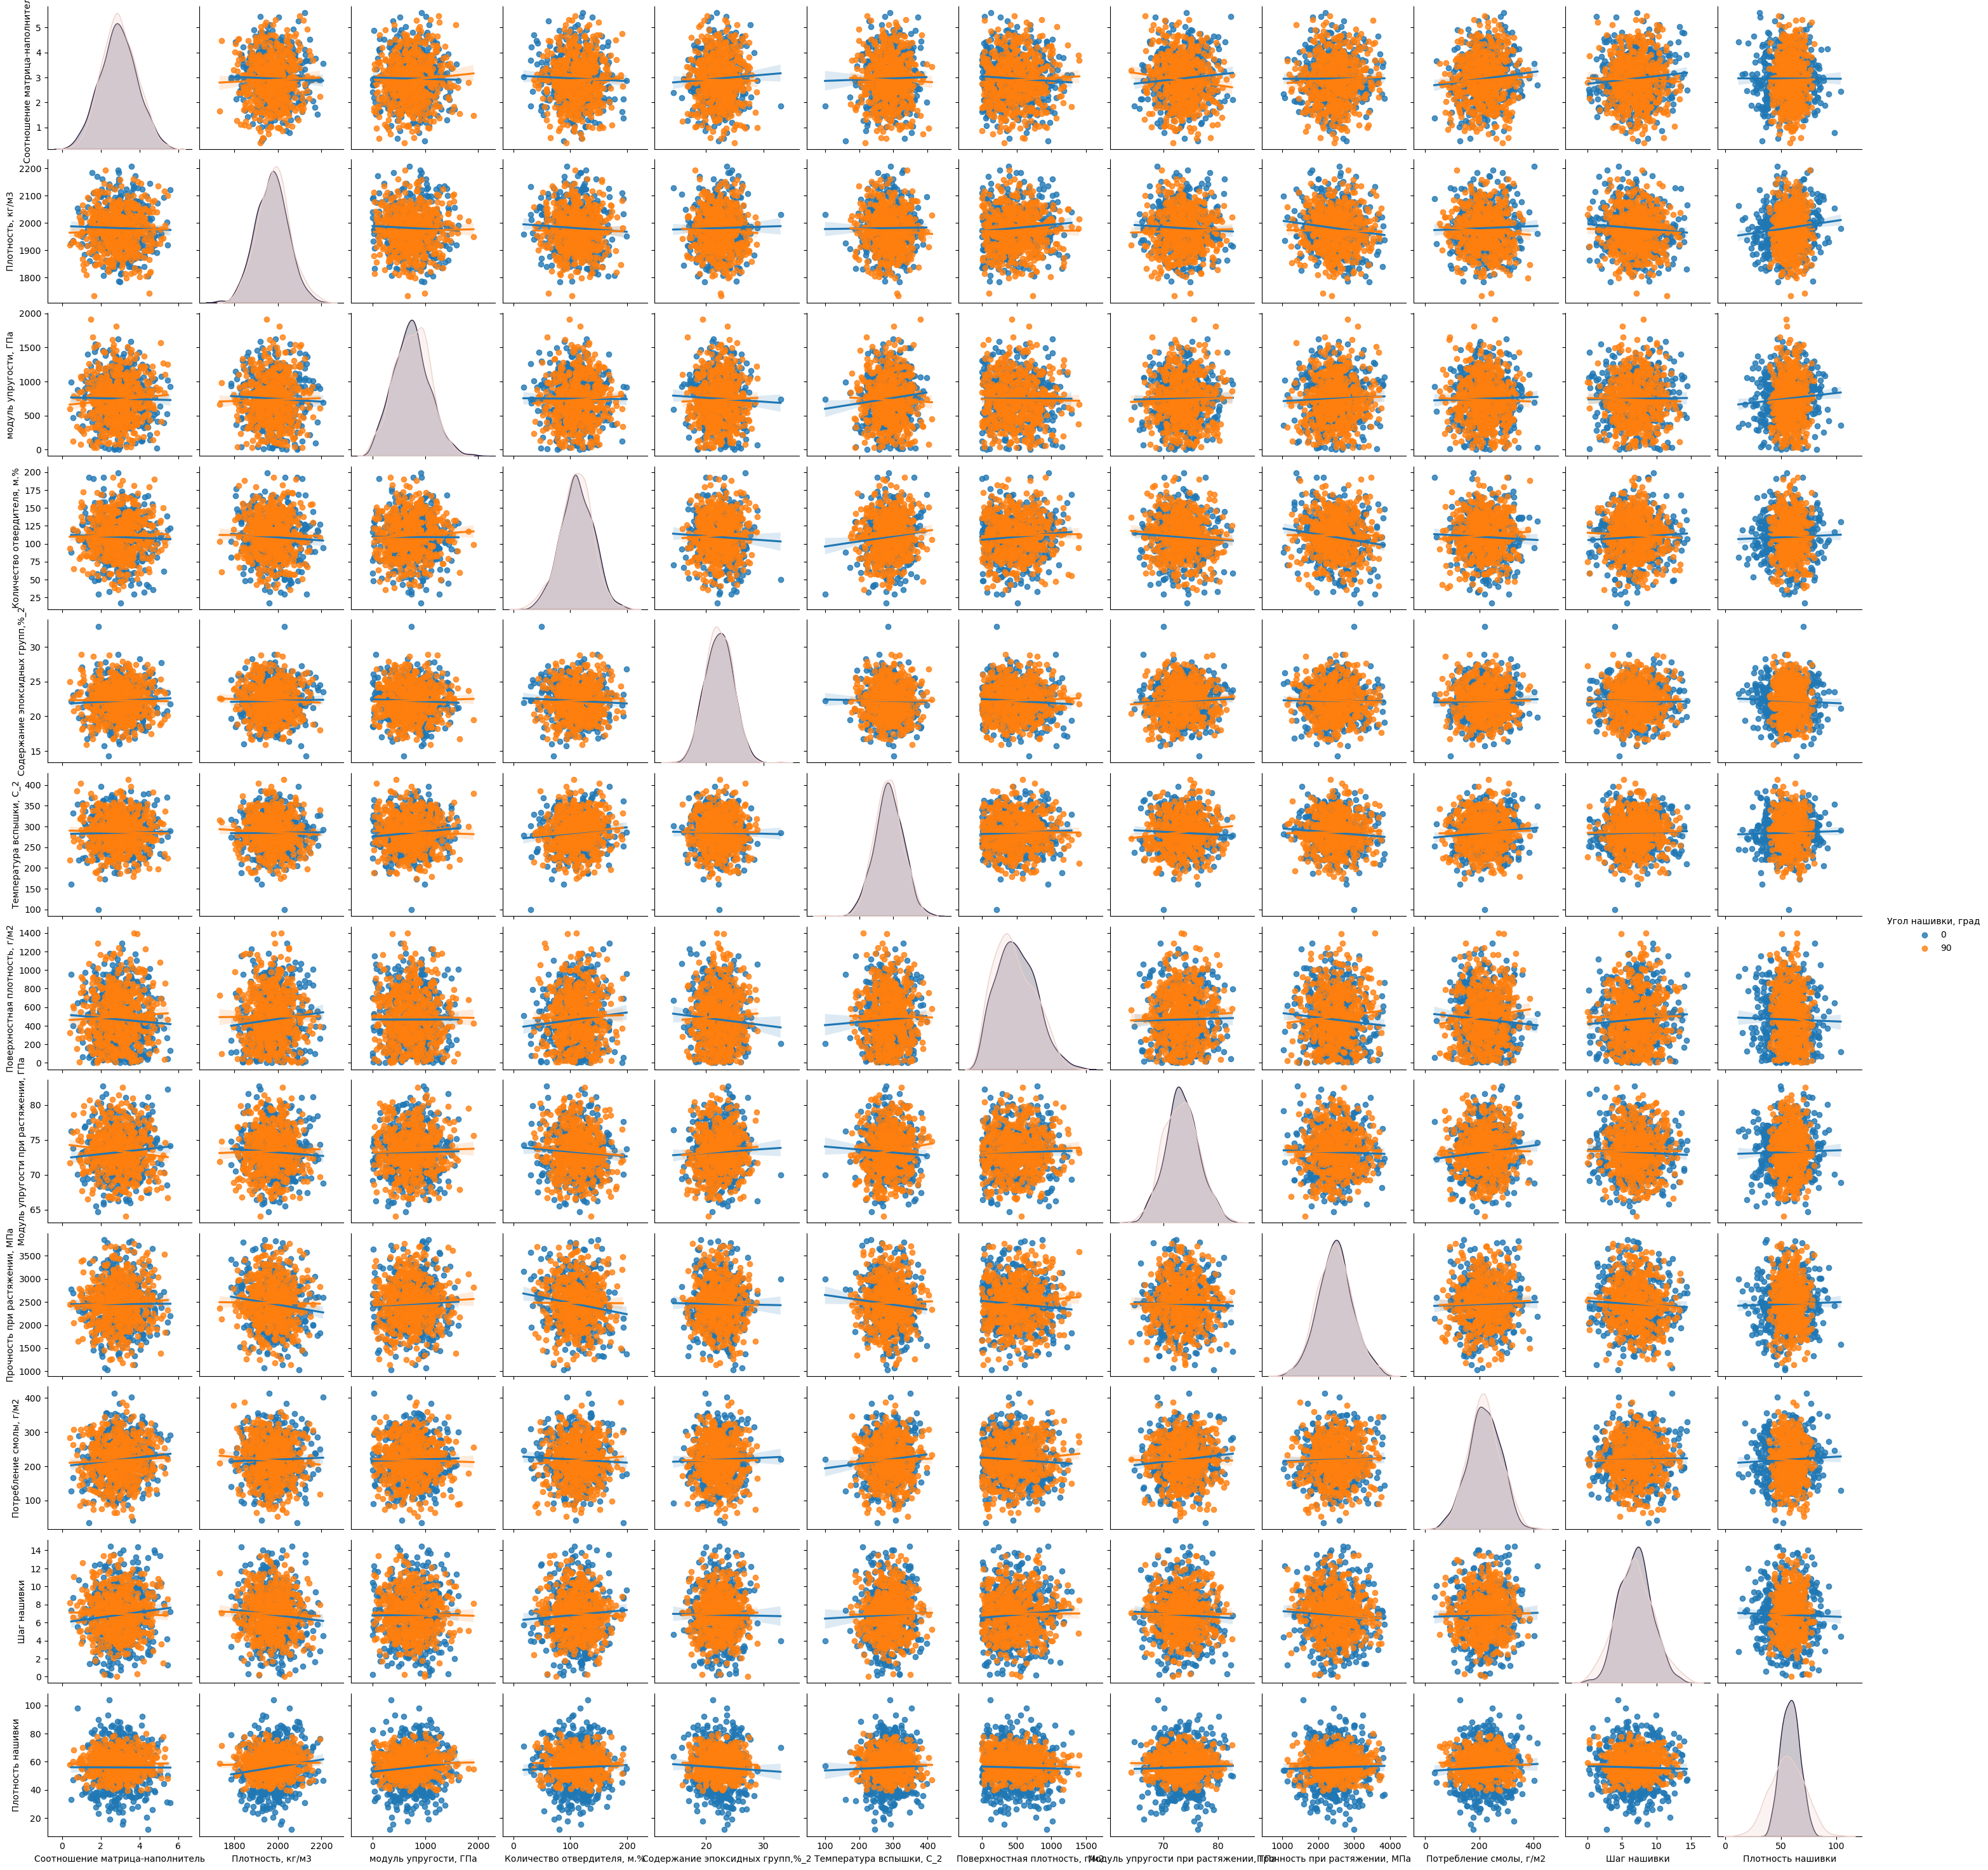

In [13]:
# Значения коэффициентов корреляции свидетельствуют об отсутствии значимых линейных связей между переменными
# Для подтверждения вывода и визуализации построим с помощью графических инструментов:
# - диаграммы рассеяния 
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(20,10), dpi= 80)
sns.pairplot(df_new, kind='reg', hue='Угол нашивки, град')
plt.show()

<Axes: >

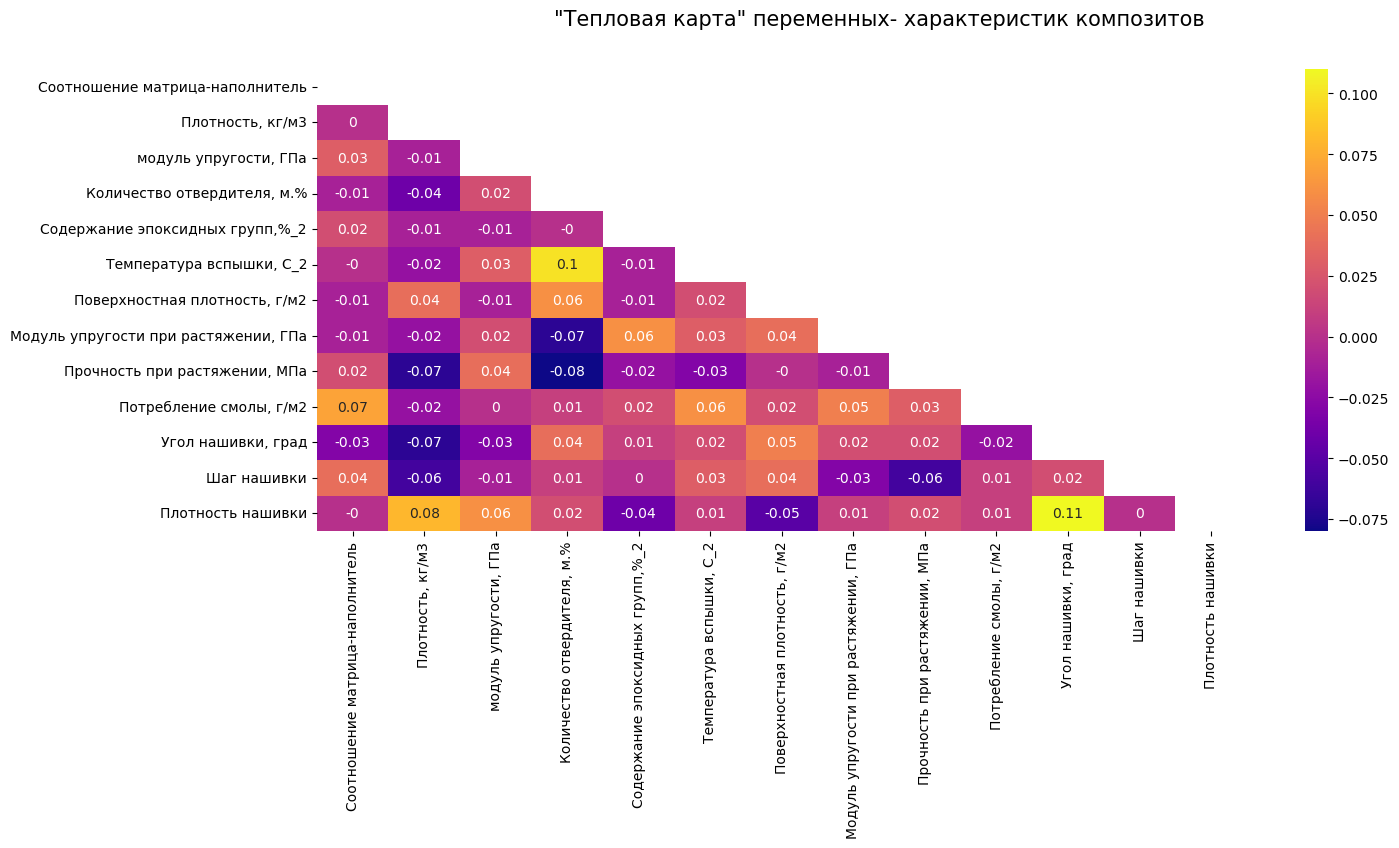

In [14]:
# -тепловую карту
plt.figure(figsize=(15,6))
plt.suptitle('"Тепловая карта" переменных- характеристик композитов', fontsize = 15)
sns.heatmap(df.corr().round(2), mask = np.triu(df_new.corr()), annot=True, cmap='plasma')

In [ ]:
# ВЫВОДЫ: 
# 1.По результатам разведочного анализа данных можно утверждать отсутствие линейной зависимости между переменными. 
# 2.Представлены результативные признаки-зависимые переменные по условию задачи (модуль упругости при растяжении,
# прочность при растяжении) и независимые переменные-факторы разных порядков, часть из которых, в свою очередь, может выступать
# как зависимая переменная для факторов более низкого уровня.
# 3.Учитывая физико-механические свойства композитных материалов и используемых в них армирующих волокон, имеют место выбросы,
# прежде всего,в переменных модуль упругости и поверхностная плотность.

In [ ]:
# Таким образом, для дальнейшей работы с данными целесообразно произвести их предобработку.

# ПРЕДОБРАБОТКА ДАННЫХ: ОЧИСТКА И НОРМАЛИЗАЦИЯ

In [16]:
print(df_new.columns)

Index(['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки'],
      dtype='object')


In [15]:
# Также для обнаружения и удаления выбросов можно использовать метод Z-показателя, метод процентилей,
# метод межквартильного размаха (IQR). На многомерных массивах лучше работают более сложно реализуемые критерии Пирсона, Колмогорова и др.
# Примерами алгоритмов использования названных методов могут быть следующие:

# Метод процентилей выявление выбросов на основе их положения в распределении данных. 
# Он удаляет точки данных, которые находятся ниже указанного нижнего процентиля или выше указанного верхнего процентиля.
def remove_outliers_percentile(df, columns, lower_percentile=0.5, upper_percentile=99.5):
    lower_bound = np.percentile(df[columns], lower_percentile, axis=0)
    upper_bound = np.percentile(df[columns], upper_percentile, axis=0)
    mask = (df_new[columns] >= lower_bound) & (df_new[columns] <= upper_bound)
    return df_new[mask]
columns_to_clean = ['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']
df_cleaned = remove_outliers_percentile(df_new, columns_to_clean)
# Применительно к нашему датасету данный метод даже при минимальных процентах "обрезания" переменных в массиве намного сокращает общий 
# объем данных.

# Метод Z-показателя
import numpy as np
from scipy import stats
def remove_outliers_zscore(df_new, columns, threshold=3):
    z_scores = stats.zscore(df_new[columns])
    mask = (z_scores < -threshold) | (z_scores > threshold)
    return df_new[~mask]
columns_to_clean = ['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']
df_cleaned = remove_outliers_zscore(df_new, columns_to_clean)

# Модифицированный метод Z-показателя для идентификации выбросов с заменой их на NaN использует медиану и медианное абсолютное
# отклонение (MAD) вместо среднего и стандартного отклонения. Метод не требует, чтобы признак, на основе которого происходит 
# поиск выбросов, был распределён нормально.
import numpy as np
from scipy import stats
columns_to_clean = ['Соотношение матрица-наполнитель', 'Плотность, кг/м3',
       'модуль упругости, ГПа', 'Количество отвердителя, м.%',
       'Содержание эпоксидных групп,%_2', 'Температура вспышки, С_2',
       'Поверхностная плотность, г/м2', 'Модуль упругости при растяжении, ГПа',
       'Прочность при растяжении, МПа', 'Потребление смолы, г/м2',
       'Угол нашивки, град', 'Шаг нашивки', 'Плотность нашивки']
def remove_outliers_robust_zscore(df_new, columns, threshold=3):
    median = df_new[columns].median()
    mad = stats.median_abs_deviation(df_new[columns])
    z_scores = 0.6745 * (df_new[columns] - median) / mad
    mask = (z_scores < -threshold) | (z_scores > threshold)
    return df_new[~mask]
df_cleaned = remove_outliers_robust_zscore(df_new, columns_to_clean)
# Применительно к нашему датасету данный метод отнес все значения угла нашивки 90 градусов к выбросам, поэтому используем другой метод.

# Метод межквартильного размаха (IQR) более грубый по очистке данных, но c помощью изменения коэффициента
# multiplier с 1,5 на 2,0 или 3,0 его можно смягчить. 
#Работает эффективно при асимметричных распределениях.
def remove_outliers_iqr(df_new, columns, multiplier=1.5):
    q1 = df_new[columns].quantile(0.25)
    q3 = df_new[columns].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (multiplier * iqr)
    upper_bound = q3 + (multiplier * iqr)
    mask = (df_new[columns] >= lower_bound) & (df_new[columns] <= upper_bound)
    return df_new[mask]
df_cleaned = remove_outliers_iqr(df_new, columns_to_clean)
df_cleaned

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.000000,738.736842,NaN,22.267857,NaN,210.000000,70.000000,3000.000000,220.000000,0,4.000000,57.000000
1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,60.000000
2,1.857143,2030.000000,738.736842,49.900000,NaN,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,70.000000
3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000,0,5.000000,47.000000
4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,57.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669,90,9.076380,47.019770
1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099,90,10.565614,53.750790
1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764,90,4.161154,67.629684
1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067,90,6.313201,58.261074


In [28]:
# Определим количество выбросов по столбцам таблицы на основе использованного метода межквартильного размаха (IQR).
df_cleaned.isna().sum()

Соотношение матрица-наполнитель          6
Плотность, кг/м3                         9
модуль упругости, ГПа                    2
Количество отвердителя, м.%             14
Содержание эпоксидных групп,%_2          2
Температура вспышки, С_2                 8
Поверхностная плотность, г/м2            2
Модуль упругости при растяжении, ГПа     6
Прочность при растяжении, МПа           11
Потребление смолы, г/м2                  8
Угол нашивки, град                       0
Шаг нашивки                              4
Плотность нашивки                       20
dtype: int64

In [16]:
# Удалим обнаруженные выбросы.
df_cleaned= df_cleaned.dropna(axis=0)
df_cleaned

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
1,1.857143,2030.000000,738.736842,50.000000,23.750000,284.615385,210.000000,70.000000,3000.000000,220.000000,0,4.000000,60.000000
3,1.857143,2030.000000,738.736842,129.000000,21.250000,300.000000,210.000000,70.000000,3000.000000,220.000000,0,5.000000,47.000000
4,2.771331,2030.000000,753.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,57.000000
5,2.767918,2000.000000,748.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,60.000000
6,2.569620,1910.000000,807.000000,111.860000,22.267857,284.615385,210.000000,70.000000,3000.000000,220.000000,0,5.000000,70.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018,2.271346,1952.087902,912.855545,86.992183,20.123249,324.774576,209.198700,73.090961,2387.292495,125.007669,90,9.076380,47.019770
1019,3.444022,2050.089171,444.732634,145.981978,19.599769,254.215401,350.660830,72.920827,2360.392784,117.730099,90,10.565614,53.750790
1020,3.280604,1972.372865,416.836524,110.533477,23.957502,248.423047,740.142791,74.734344,2662.906040,236.606764,90,4.161154,67.629684
1021,3.705351,2066.799773,741.475517,141.397963,19.246945,275.779840,641.468152,74.042708,2071.715856,197.126067,90,6.313201,58.261074


In [17]:
# Описательная статистика полученного датасета. Обращает на себя внимание сохранение крайне низких значений показателя поверхностной 
# плотности(за пределами реальных физических характеристик материалов).В связи с чем удаляем строки со значением плотности менее 12 г/м2
df_cleaned= df_cleaned.drop(df_cleaned[df_cleaned['Поверхностная плотность, г/м2'] < 12].index)
df_cleaned.describe()

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,2.926307,1974.029569,739.551180,111.044425,22.199022,286.048775,488.139080,73.314194,2470.105431,217.660709,46.166307,6.919055,57.407954
std,0.894062,70.498093,327.567455,26.971768,2.398415,39.479659,277.262832,3.048756,461.760034,57.818439,45.009193,2.517210,11.241334
min,0.547391,1784.482245,2.436909,38.668500,15.695894,179.374391,12.040487,65.553336,1250.392802,63.685698,0.000000,0.037639,27.272928
25%,2.320191,1923.521521,501.560124,92.619058,20.554570,259.205321,271.342426,71.225212,2150.952583,179.719792,0.000000,5.132313,50.212270
50%,2.903269,1977.258043,738.847005,111.162090,22.180360,286.024118,462.275850,73.269373,2457.959767,218.697660,90.000000,6.972862,57.561236
75%,3.545717,2019.842447,957.391294,130.109815,23.961585,313.012786,696.513284,75.322715,2754.226864,256.268018,90.000000,8.601424,64.609067
max,5.314144,2161.565216,1649.415706,181.828448,28.955094,386.067992,1291.340115,81.417126,3705.672523,359.052220,90.000000,13.732404,86.012427


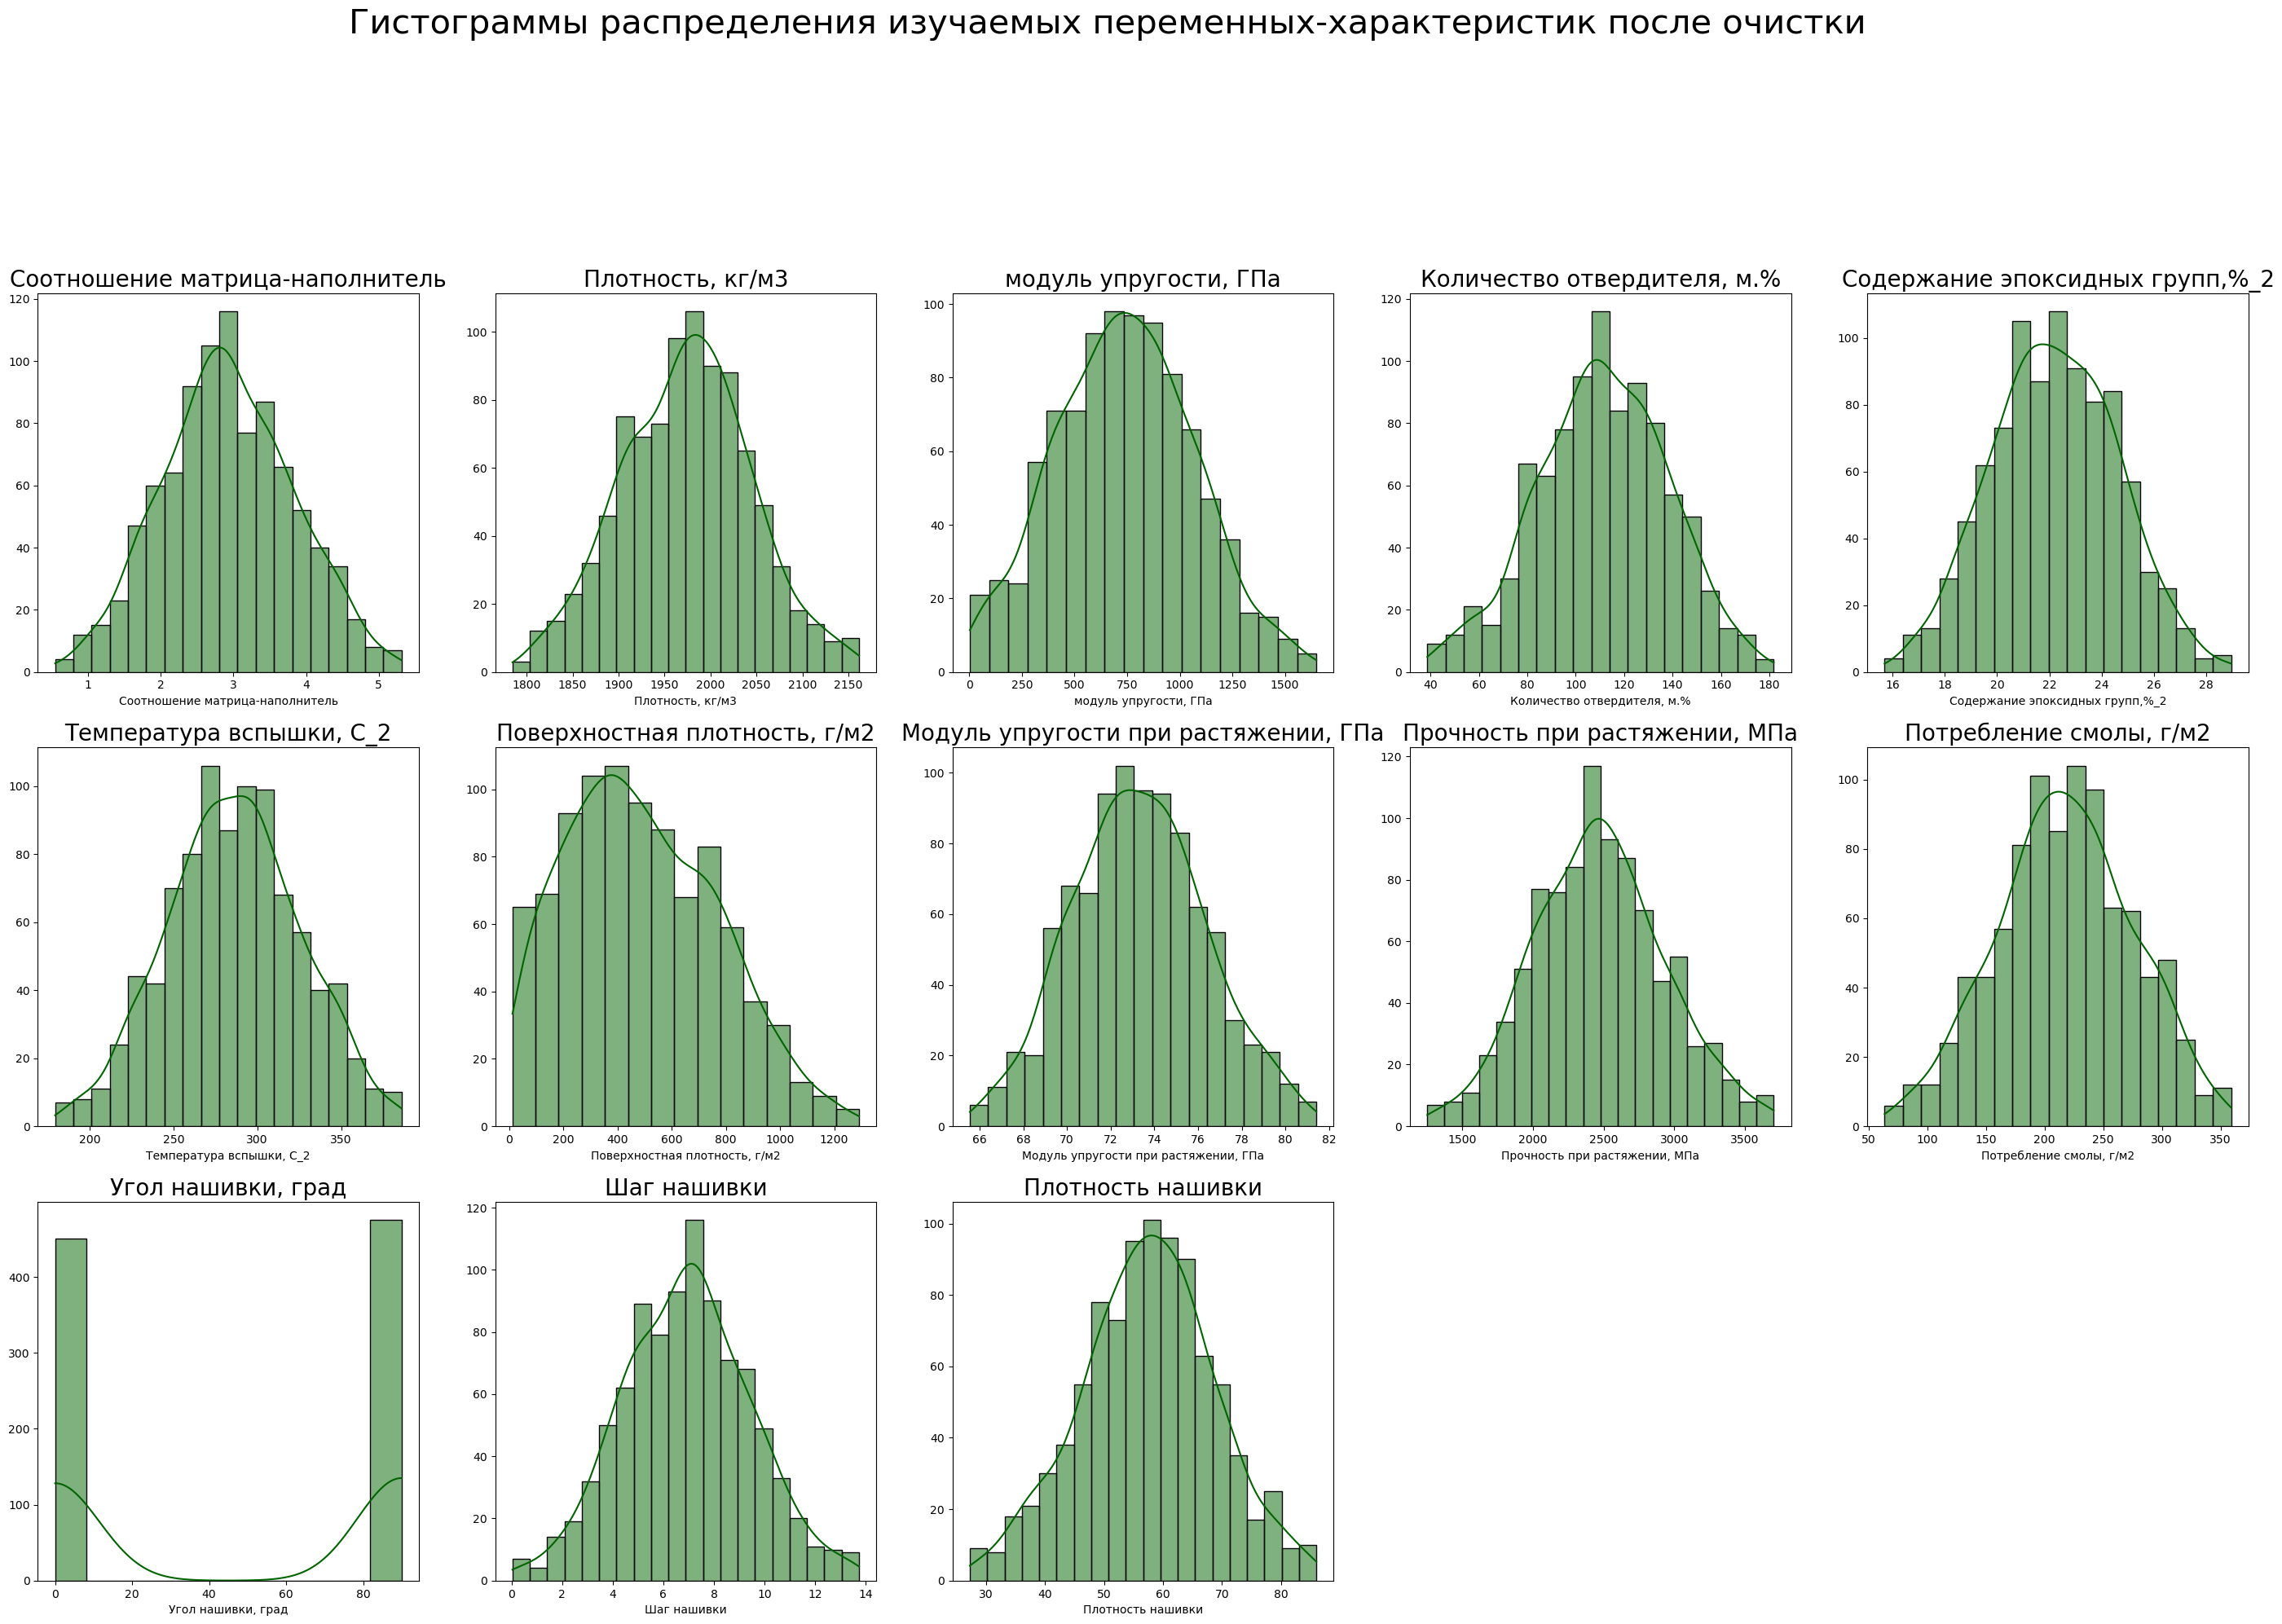

In [18]:
# Посмотрим после очистки данных на их распределение, чтобы понять, насколько оно близки к нормальному перед последующей предобработкой.
df_cleaned.columns
column_names = df_cleaned.columns
a = 5 # количество строк
b = 5 # количество столцбцов
c = 1 # запуск plot counter
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize = (35,35))
plt.suptitle('Гистограммы распределения изучаемых переменных-характеристик после очистки', fontsize = 30)
for col in df_cleaned.columns:
    plt.subplot(a, b, c)
    sns.histplot(data = df_cleaned[col], kde=True, color = "darkgreen")
    plt.ylabel(None)
    plt.title(col, size = 20)
    c += 1

In [127]:
# Визуально часть переменных подчиняется нормальному закону распределения.Однако в отношении таких переменных,
# как модуль упругости, поверхностная плотность, количество отвердителя, плотность нашивки, угол нашивки имеет место иной тип распределения 
# (например, логнормальный).
# Для проверки нормальности распределения очищенных данных по указанным переменным прибегнем к тесту Шапиро-Уилка.
from scipy.stats import shapiro
data = df_cleaned["модуль упругости, ГПа"]
def shapiro_test(data, alpha=0.05):
    stat, p = shapiro(data)
    if p > alpha:
        print('Данные выглядят как нормальные (гауссовские)')
    else:
        print('Данные не выглядят как нормальные (гауссовские)')
shapiro_test(df_cleaned["модуль упругости, ГПа"])

Данные не выглядят как нормальные (гауссовские)


In [128]:
from scipy.stats import shapiro
data = df_cleaned["Плотность нашивки"]
def shapiro_test(data, alpha=0.05):
    stat, p = shapiro(data)
    if p > alpha:
        print('Данные выглядят как нормальные (гауссовские)')
    else:
        print('Данные не выглядят как нормальные (гауссовские)')
shapiro_test(df_cleaned["Плотность нашивки"])

Данные не выглядят как нормальные (гауссовские)


In [126]:
from scipy.stats import shapiro
data = df_cleaned["Поверхностная плотность, г/м2"]
def shapiro_test(data, alpha=0.05):
    stat, p = shapiro(data)
    if p > alpha:
        print('Данные выглядят как нормальные (гауссовские)')
    else:
        print('Данные не выглядят как нормальные (гауссовские)')
shapiro_test(df_cleaned["Поверхностная плотность, г/м2"])

Данные не выглядят как нормальные (гауссовские)


In [129]:
from scipy.stats import shapiro
data = df_cleaned["Количество отвердителя, м.%"]
def shapiro_test(data, alpha=0.05):
    stat, p = shapiro(data)
    if p > alpha:
        print('Данные выглядят как нормальные (гауссовские)')
    else:
        print('Данные не выглядят как нормальные (гауссовские)')
shapiro_test(df_cleaned["Количество отвердителя, м.%"])

Данные не выглядят как нормальные (гауссовские)


In [47]:
# Учитывая результаты проверки на нормальность распределения и разность масштабов значений переменных, нужно провести нормализацию данных 
# для последующего анализа, т.е. привести данные к единой шкале без искажения различий в диапазонах значений.
df_norm = df_cleaned.copy() # работаем на создаваемой копии предыдущего массива, чтобы сохранить его на случай ошибок в обработке
df_norm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 926 entries, 1 to 1022
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Соотношение матрица-наполнитель       926 non-null    float64
 1   Плотность, кг/м3                      926 non-null    float64
 2   модуль упругости, ГПа                 926 non-null    float64
 3   Количество отвердителя, м.%           926 non-null    float64
 4   Содержание эпоксидных групп,%_2       926 non-null    float64
 5   Температура вспышки, С_2              926 non-null    float64
 6   Поверхностная плотность, г/м2         926 non-null    float64
 7   Модуль упругости при растяжении, ГПа  926 non-null    float64
 8   Прочность при растяжении, МПа         926 non-null    float64
 9   Потребление смолы, г/м2               926 non-null    float64
 10  Угол нашивки, град                    926 non-null    int64  
 11  Шаг нашивки            

In [57]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [68]:
from sklearn import preprocessing
import numpy as np 
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
min_max_scaler = preprocessing.MinMaxScaler()
col = df_norm.columns
result = scaler.fit_transform(df_norm)
df_norm = pd.DataFrame(min_max_scaler.fit_transform(df_norm), columns=df_norm.columns)
print(df_norm.head())
df_norm.describe()

   Соотношение матрица-наполнитель  Плотность, кг/м3  модуль упругости, ГПа  \
0                         0.274768          0.651097               0.447061   
1                         0.274768          0.651097               0.447061   
2                         0.466552          0.651097               0.455721   
3                         0.465836          0.571539               0.452685   
4                         0.424236          0.332865               0.488508   

   Количество отвердителя, м.%  Содержание эпоксидных групп,%_2  \
0                     0.079153                         0.607435   
1                     0.630983                         0.418887   
2                     0.511257                         0.495653   
3                     0.511257                         0.495653   
4                     0.511257                         0.495653   

   Температура вспышки, С_2  Поверхностная плотность, г/м2  \
0                  0.509164                       0.154741  

,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
count,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000,926.000000
mean,0.499064,0.502667,0.447555,0.505560,0.490462,0.516099,0.372156,0.489218,0.496771,0.521302,0.512959,0.502485,0.513028
std,0.187562,0.186956,0.198890,0.188403,0.180887,0.191006,0.216730,0.192183,0.188068,0.195751,0.500102,0.183808,0.191376
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.371909,0.368723,0.303054,0.376855,0.366438,0.386228,0.202691,0.357536,0.366785,0.392848,0.000000,0.372016,0.390527
50%,0.494231,0.511229,0.447128,0.506382,0.489054,0.515980,0.351939,0.486393,0.491825,0.524812,1.000000,0.506414,0.515638
75%,0.629008,0.624160,0.579822,0.638735,0.623393,0.646553,0.535037,0.615829,0.612490,0.652011,1.000000,0.625333,0.635622
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


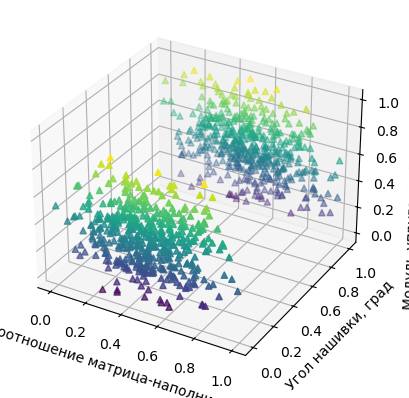

In [92]:
# Для дальнейшего анализа можно построить серию 3D визуализаций предполагаемых зависимостей изучаемых переменных 
# после очистки и нормализации данных.
# В качестве примера анализа влияния независимых переменных используем в одном случае соотношение матрица-наполнитель и угол нашивки,
# в другом- содержание эпоксидных групп и поверхностную плотность, в качестве целевой переменной- модуль упругости при растяжении.
# На первом полученном 3d изображении визуально видна тенденция роста модуля упругости при росте соотношения
# матрицы-наполнителя и увеличении угля нашивки.
# На втором изображении визуально сложно обнаружить такую зависимость.
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')

x = df_norm['Соотношение матрица-наполнитель']
y = df_norm['Угол нашивки, град']
z = df_norm['Модуль упругости при растяжении, ГПа']
colors = z
ax.set_xlabel("Соотношение матрица-наполнитель")
ax.set_ylabel("Угол нашивки, град")
ax.set_zlabel("Модуль упругости при растяжении, ГПа")
ax.scatter(x, y, z, c=colors, cmap='viridis', marker='^')
plt.show()

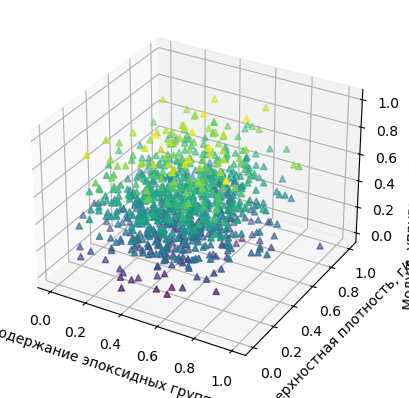

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
x = df_norm['Содержание эпоксидных групп,%_2']
y = df_norm['Поверхностная плотность, г/м2']
z = df_norm['Модуль упругости при растяжении, ГПа']
colors = z
ax.set_xlabel("Содержание эпоксидных групп,%_2")
ax.set_ylabel("Поверхностная плотность, г/м2")
ax.set_zlabel("Модуль упругости при растяжении, ГПа")
ax.scatter(x, y, z, c=colors, cmap='viridis', marker='^')
plt.show()

<Axes: ylabel='Density'>

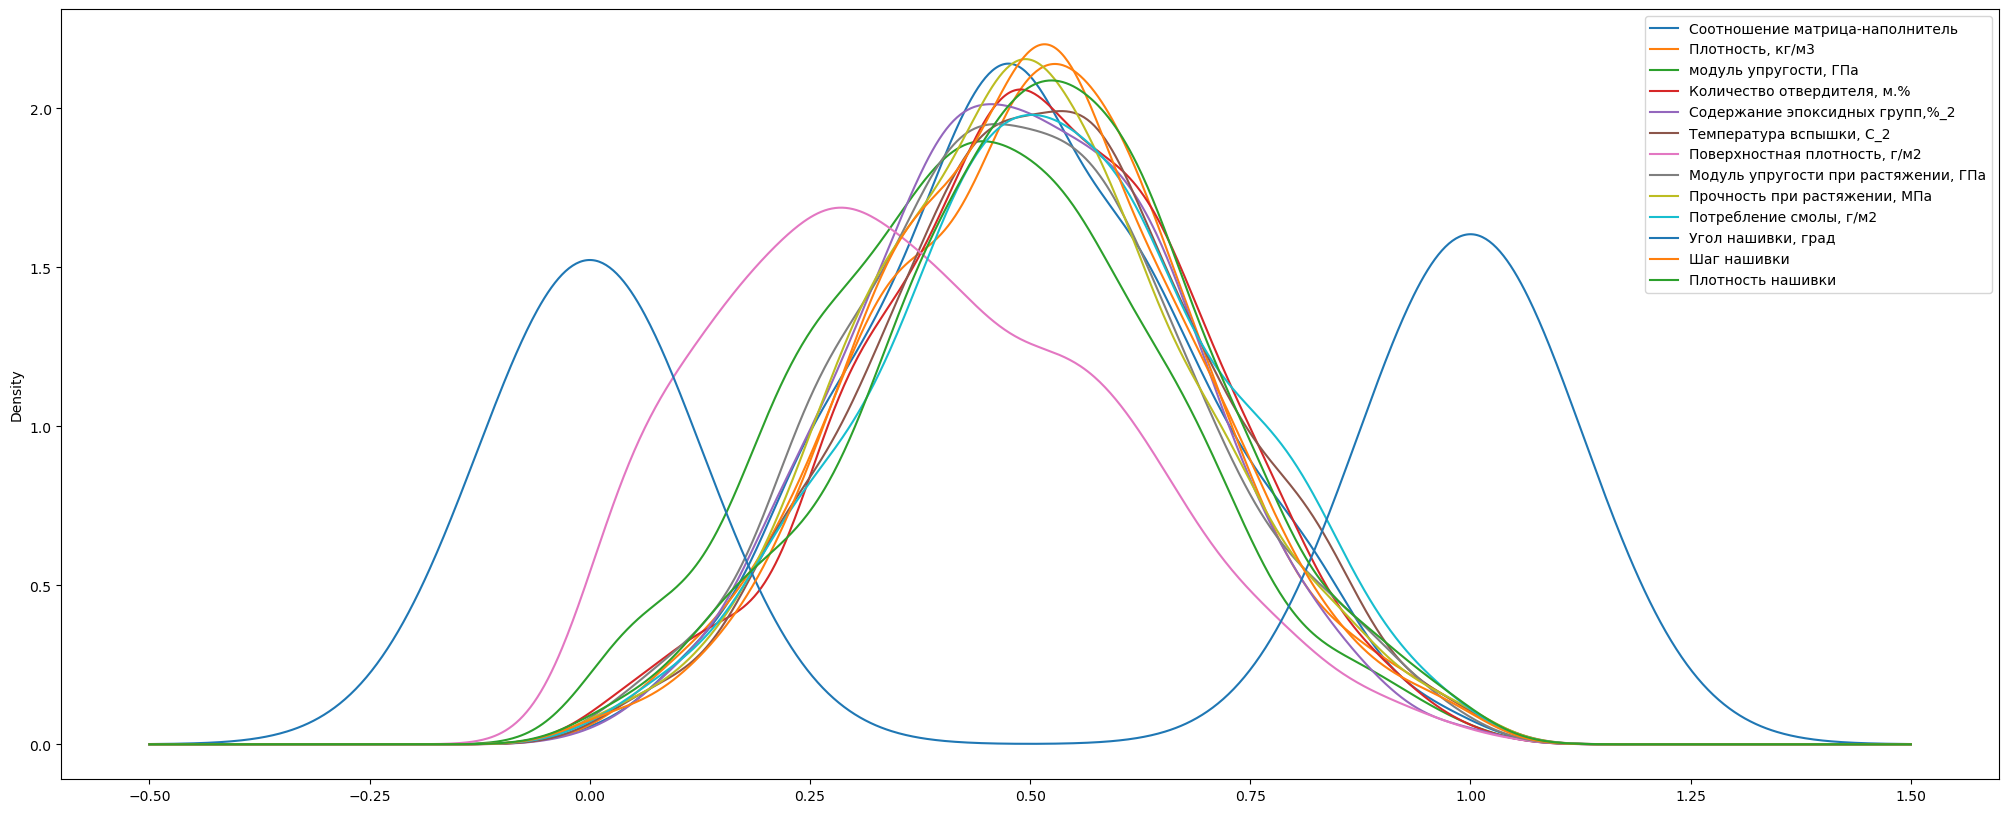

In [109]:
# Отразим также на одной сетке графики полученных нормализованных переменных.
fig, ax = plt.subplots(figsize=(25, 10))
df_norm.plot(kind='kde', ax=ax)

In [ ]:
# В рамках предобработки также часто используется стандартизация данных. 
# Она хорошо работает в случаях гауссовского/нормального распределения. Используется обращение к StandardScaler. 
# В нашем случае считаем, что на данном этапе она избыточна.
# Для целей построения моделей машинного обучения  на вход будут подаваться нормализованные значения независимых перменных, целевой показатель
# в тренировочной части выборки будет браться в фактических значениях.

In [62]:
# Сохраним полученные в результате обработки данные в Excel файлы для продолжения работы с ними во втором разделе
!pip install xlwt
df_cleaned.to_excel('Файл очищенные данные.xlsx', index=False)
df_norm.to_excel('Файл нормализ.данные.xlsx', index=False)